### Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### Carga y drop inicial

In [2]:
## Datos Indice nino RONI, Fuente: https://psl.noaa.gov/data/timeseries/month/DS/RONI/
df_roni = pd.read_csv("data/indicesNOAA/nino34_Index.csv")
df_roni = df_roni[(df_roni['Date'] >= "2000-01-01") & (df_roni['Date'] <= "2024-12-31")]
df_roni.rename(columns={df_roni.columns[1]: 'RONI', df_roni.columns[0]: 'date'}, inplace=True)

## Datos Precio de Energia, Fuente: https://sinergox.xm.com.co/trpr/Paginas/Historicos/Historicos.aspx
df_energyPrice = pd.read_csv("data//XM/Procesadas/price_energy_monthly_2000-2024.csv")
df_energyPrice.rename(columns={df_energyPrice.columns[1]: 'ENERGY_PRICE'}, inplace=True)

## Datos Aportes de caudal, Fuente: https://sinergox.xm.com.co/hdrlg/Paginas/Historicos/Historicos.aspx
df_aportes = pd.read_csv("data//XM/Procesadas/aportes_KWH_monthly_2000-2024.csv")
df_aportes.rename(columns={df_aportes.columns[1]: 'APORTES'}, inplace=True)

## Datos Generacion, Fuente: https://sinergox.xm.com.co/oferta/Paginas/Historicos/Historicos.aspx
df_generation = pd.read_csv("data//XM/Procesadas/generacion_monthly_2000-2024.csv")
df_generation.rename(columns={df_generation.columns[1]: 'GENERATION'}, inplace=True)

### Misma Frecuencia (Tecnica Valor Promedio Mensual)

In [3]:
# Copias para no afectacion:
serie_roni = df_roni.copy()
serie_energyPrice = df_energyPrice.copy()
serie_aportes = df_aportes.copy()
serie_generation = df_generation.copy()

# Formato Serie:
serie_roni['date'] = pd.to_datetime(serie_roni['date'])
serie_energyPrice['date'] = pd.to_datetime(serie_energyPrice['date'])
serie_aportes['date'] = pd.to_datetime(serie_aportes['date'])
serie_generation['date'] = pd.to_datetime(serie_generation['date'])

# Serie con indice Fecha:
serie_roni.set_index('date', inplace=True)
serie_energyPrice.set_index('date', inplace=True)
serie_aportes.set_index('date', inplace=True)
serie_generation.set_index('date', inplace=True)

# Series impresas:
print(serie_energyPrice.head())
print(serie_roni.head())
print(serie_aportes.head())
print(serie_generation.head())


            ENERGY_PRICE
date                    
2000-01-01     36.778780
2000-02-01     40.261477
2000-03-01     37.637297
2000-04-01     44.298057
2000-05-01     37.291122
            RONI
date            
2000-01-01 -1.79
2000-02-01 -1.53
2000-03-01 -1.26
2000-04-01 -0.80
2000-05-01 -0.80
                 APORTES
date                    
2000-01-01  1.055922e+08
2000-02-01  1.107575e+08
2000-03-01  1.251867e+08
2000-04-01  1.349806e+08
2000-05-01  2.676612e+08
              GENERATION
date                    
2000-01-01  7.944395e+07
2000-02-01  7.146242e+07
2000-03-01  8.386839e+07
2000-04-01  7.508375e+07
2000-05-01  8.722126e+07


### Merge

In [4]:
serie = pd.concat(
    [serie_roni, serie_energyPrice, serie_aportes, serie_generation],
    axis=1
)

serie.head()

,RONI,ENERGY_PRICE,APORTES,GENERATION
date,,,,
2000-01-01,-1.79,36.778780,1.055922e+08,7.944395e+07
2000-02-01,-1.53,40.261477,1.107575e+08,7.146242e+07
2000-03-01,-1.26,37.637297,1.251867e+08,8.386839e+07
2000-04-01,-0.80,44.298057,1.349806e+08,7.508375e+07
2000-05-01,-0.80,37.291122,2.676612e+08,8.722126e+07


### Visualizacion:

#### RONI vs ENERGY_PRICE

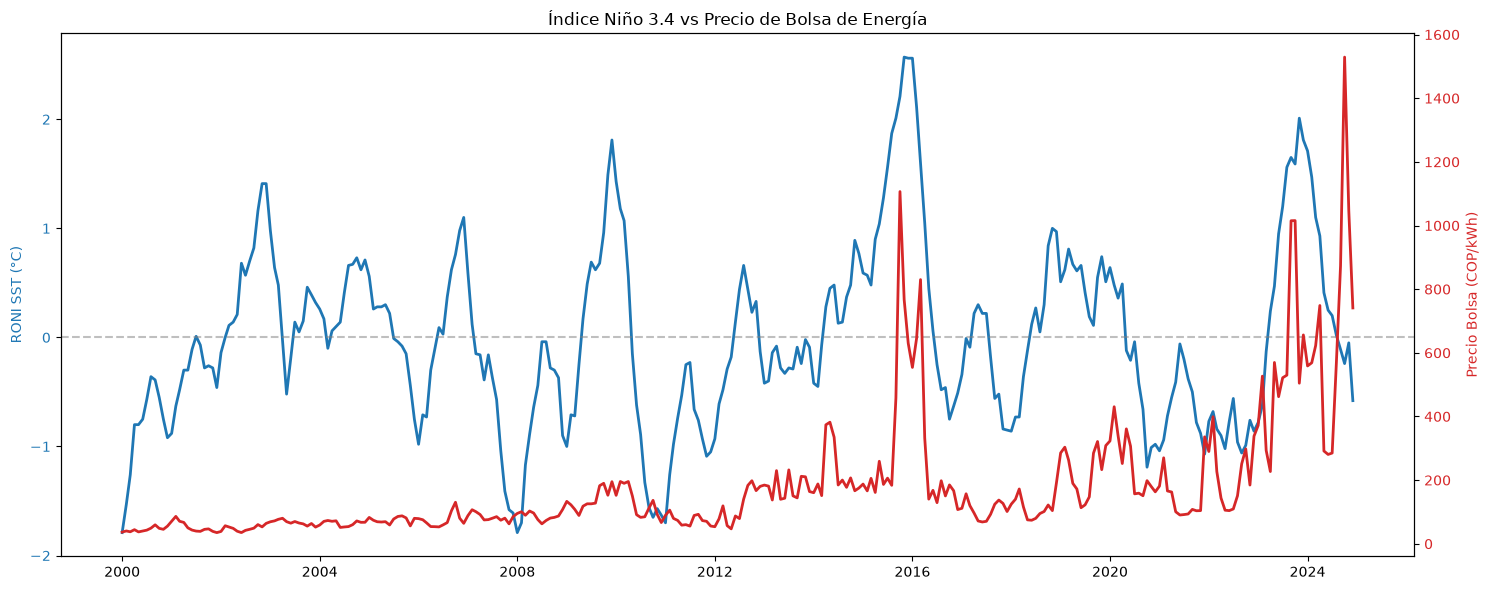

In [5]:
# Crear figura
fig, ax1 = plt.subplots(figsize=(15,6))

# ==========================
# Eje izquierdo (Niño)
# ==========================
ax1.plot(
    serie.index,
    serie["RONI"],
    color="tab:blue",
    linewidth=2,
    label="RONI"
)

ax1.set_ylabel("RONI SST (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Línea horizontal en cero
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)

# ==========================
# Eje derecho (Precio Energía)
# ==========================
ax2 = ax1.twinx()

ax2.plot(
    serie.index,
    serie["ENERGY_PRICE"],
    color="tab:red",
    linewidth=2,
    label="Precio Energía"
)

ax2.set_ylabel("Precio Bolsa (COP/kWh)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ==========================
# Título
# ==========================
plt.title("Índice Niño 3.4 vs Precio de Bolsa de Energía")

plt.tight_layout()

plt.show()

#### RONI vs APORTES

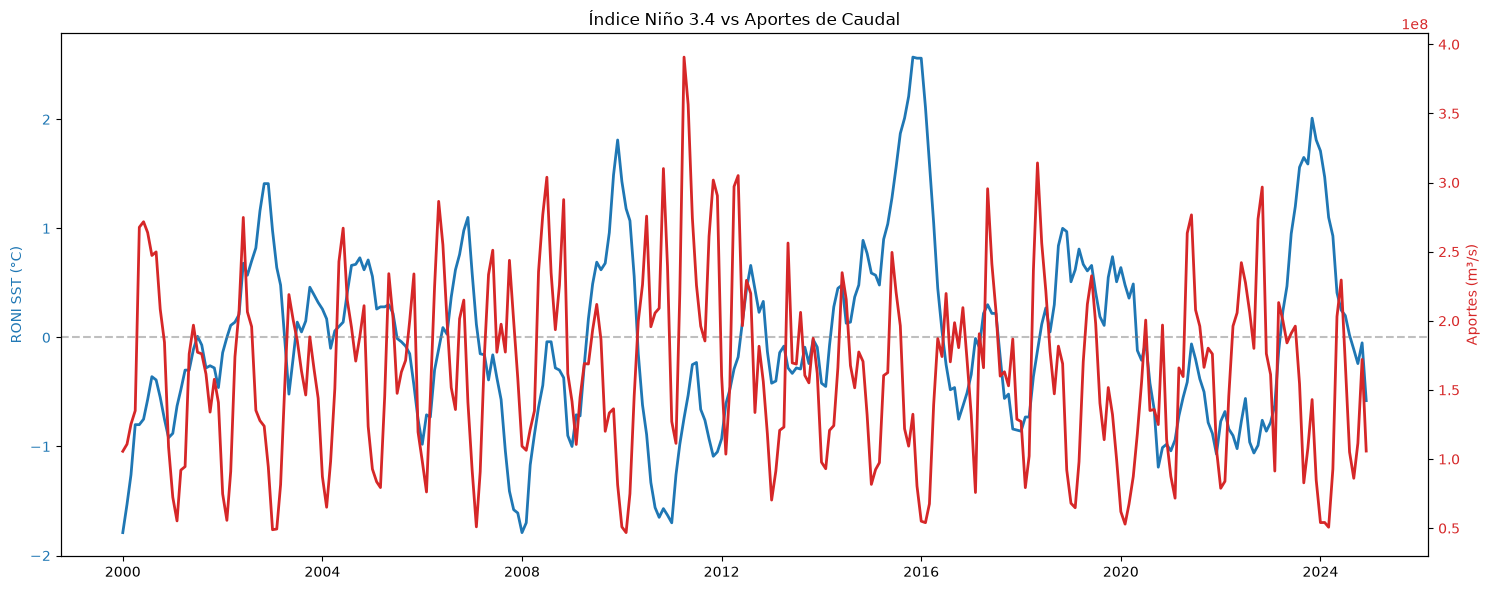

In [6]:
# Crear figura
fig, ax1 = plt.subplots(figsize=(15,6))

# ==========================
# Eje izquierdo (Niño)
# ==========================
ax1.plot(
    serie.index,
    serie["RONI"],
    color="tab:blue",
    linewidth=2,
    label="RONI"
)

ax1.set_ylabel("RONI SST (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Línea horizontal en cero
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)

# ==========================
# Eje derecho (Precio Energía)
# ==========================
ax2 = ax1.twinx()

ax2.plot(
    serie.index,
    serie["APORTES"],
    color="tab:red",
    linewidth=2,
    label="Aportes"
)

ax2.set_ylabel("Aportes (m³/s)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ==========================
# Título
# ==========================
plt.title("Índice Niño 3.4 vs Aportes de Caudal")

plt.tight_layout()

plt.show()

#### RONI vs GENERACION

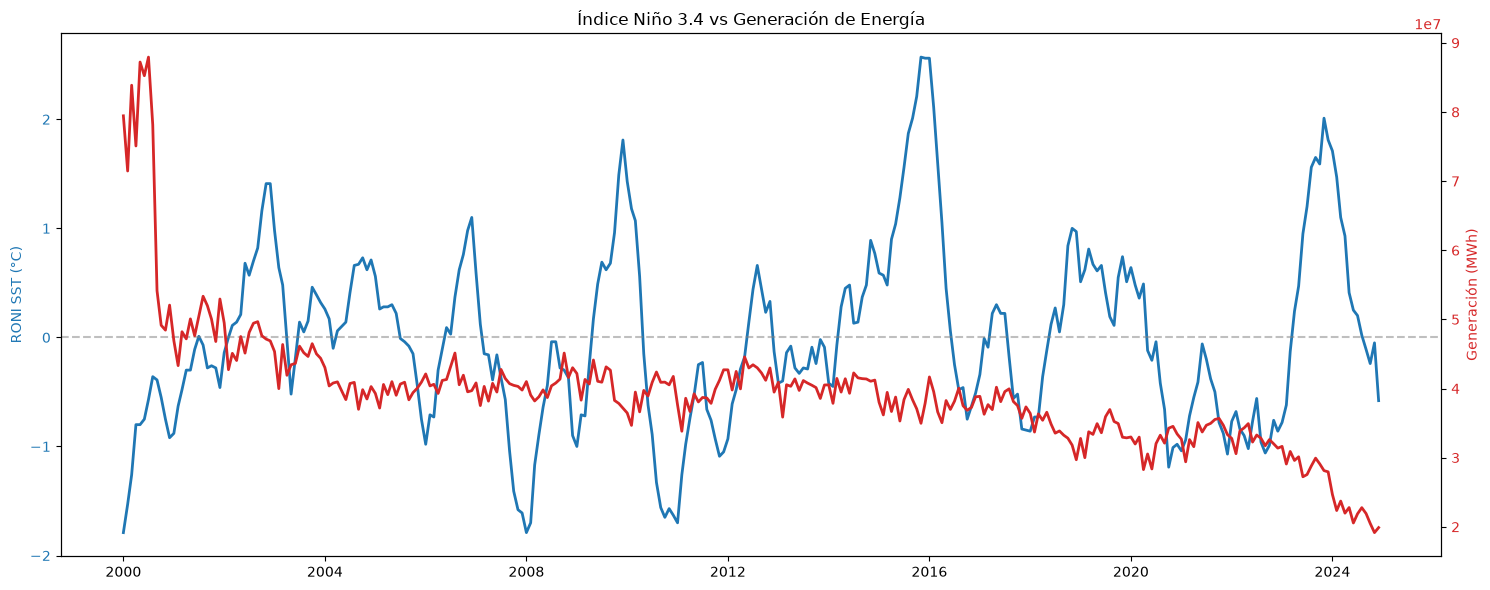

In [7]:
# Crear figura
fig, ax1 = plt.subplots(figsize=(15,6))

# ==========================
# Eje izquierdo (Niño)
# ==========================
ax1.plot(
    serie.index,
    serie["RONI"],
    color="tab:blue",
    linewidth=2,
    label="RONI"
)

ax1.set_ylabel("RONI SST (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Línea horizontal en cero
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)

# ==========================
# Eje derecho (Precio Energía)
# ==========================
ax2 = ax1.twinx()

ax2.plot(
    serie.index,
    serie["GENERATION"],
    color="tab:red",
    linewidth=2,
    label="Generación"
)

ax2.set_ylabel("Generación (MWh)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ==========================
# Título
# ==========================
plt.title("Índice Niño 3.4 vs Generación de Energía")

plt.tight_layout()

plt.show()

In [8]:
output_folder = Path(r"data")

output_folder.mkdir(parents=True, exist_ok=True)

serie.to_csv(
    output_folder / "RONI_APORTES_PRICE_GENERATION_monthly_2000-2024.csv",
    index=True
)